# Irrigation Need — Notebook 3: LightGBM
**Kaggle Playground S6E4**

Inputs:
- `Data/processed/train_unscaled.parquet`
- `Data/processed/test_unscaled.parquet`
- `Data/processed/sample_weights.parquet`
- `Data/processed/class_weights.pkl`
- `Data/processed/target_map.pkl`

Output:
- `submissions/submission_lgbm.csv`
- `models/lgbm_best_params.pkl`
- `models/lgbm_oof_preds.parquet`

Strategy:
1. Baseline — formula argmax only (no ML)
2. Optuna hyperparameter search — 5-fold stratified CV
3. Final model — retrain on full data with best params
4. OOF predictions saved for ensemble notebook


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

pd.set_option('display.float_format', '{:.4f}'.format)
PALETTE = {'Low': '#02C39A', 'Medium': '#F4A261', 'High': '#E63946'}
SEED = 42
N_FOLDS = 5
N_TRIALS = 75

os.makedirs('../models', exist_ok=True)
os.makedirs('../submissions', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
train = pd.read_parquet('../Data/processed/train_unscaled.parquet')
test  = pd.read_parquet('../Data/processed/test_unscaled.parquet')

with open('../Data/processed/class_weights.pkl', 'rb') as f:
    cw = pickle.load(f)
class_weight_dict = cw['class_weight_dict']

with open('../Data/processed/target_map.pkl', 'rb') as f:
    tm = pickle.load(f)
target_inv = tm['inv']  # {0: 'Low', 1: 'Medium', 2: 'High'}

sample_weights = pd.read_parquet('../Data/processed/sample_weights.parquet')['sample_weight'].values

y = train['Irrigation_Need'].values
X = train.drop(columns=['Irrigation_Need'])
X_test = test.copy()

print(f'Train: {X.shape}  |  Test: {X_test.shape}')
print(f'Target distribution: {pd.Series(y).value_counts().to_dict()}')
print(f'Class weights: {class_weight_dict}')
print(f'Features: {X.columns.tolist()}')

Train: (630000, 37)  |  Test: (270000, 37)
Target distribution: {0: 369917, 1: 239074, 2: 21009}
Class weights: {0: 0.5676949153458749, 1: 0.8783891180136694, 2: 9.995716121662145}
Features: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10', 'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative', 'mulch_no', 'mulch_yes', 'logit_low', 'logit_medium', 'logit_high', 'prob_low', 'prob_medium', 'prob_high', 'rule_score', 'logit_margin']


## 2. Baseline — Formula Only (No ML)

Formula baseline — Balanced Accuracy: 0.9610

Classification report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.92      0.92      0.92     21009

    accuracy                           0.98    630000
   macro avg       0.96      0.96      0.96    630000
weighted avg       0.98      0.98      0.98    630000



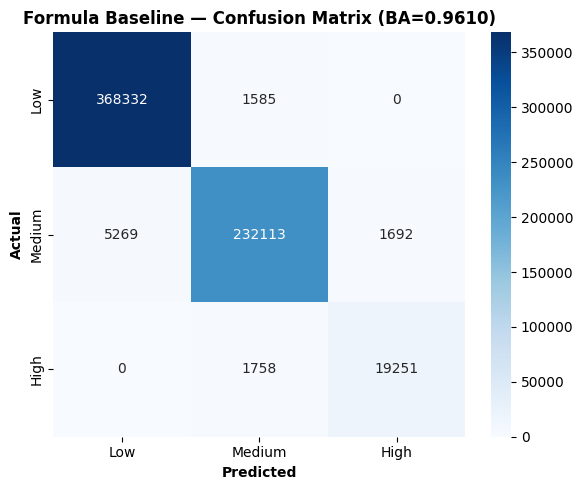


Target to beat: 0.9610


In [3]:
# Formula argmax from prob columns computed in notebook 2
prob_cols = ['prob_low', 'prob_medium', 'prob_high']
formula_pred = np.argmax(X[prob_cols].values, axis=1)

ba_formula = balanced_accuracy_score(y, formula_pred)
print(f'Formula baseline — Balanced Accuracy: {ba_formula:.4f}')
print(f'\nClassification report:')
print(classification_report(
    y, formula_pred,
    target_names=['Low', 'Medium', 'High']
))

# Confusion matrix
cm = confusion_matrix(y, formula_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title(f'Formula Baseline — Confusion Matrix (BA={ba_formula:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTarget to beat: {ba_formula:.4f}')

## 3. Feature Sets

In [4]:
# We test two feature sets:
# A — all features (original + formula-derived)
# B — formula-derived only (ablation: does adding original features help?)

formula_cols = [
    'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10',
    'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative',
    'mulch_no', 'mulch_yes',
    'logit_low', 'logit_medium', 'logit_high',
    'prob_low', 'prob_medium', 'prob_high',
    'rule_score', 'logit_margin'
]

all_features     = X.columns.tolist()
formula_features = [c for c in formula_cols if c in X.columns]

print(f'Feature set A (all):     {len(all_features)} features')
print(f'Feature set B (formula): {len(formula_features)} features')

# We will run Optuna on feature set A (all features)
# and do a quick 5-fold eval on feature set B for comparison
FEATURE_COLS = all_features
print(f'\nUsing feature set A for Optuna.')

Feature set A (all):     37 features
Feature set B (formula): 18 features

Using feature set A for Optuna.


## 4. Quick Ablation — Formula Features Only

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

base_params = {
    'objective':    'multiclass',
    'num_class':    3,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves':   31,
    'random_state': SEED,
}

def quick_cv(feature_cols, label):
    scores = []
    X_sub = X[feature_cols].values
    for tr_idx, val_idx in skf.split(X_sub, y):
        X_tr, X_val = X_sub[tr_idx], X_sub[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        sw_tr = sample_weights[tr_idx]
        model = lgb.LGBMClassifier(**base_params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        preds = model.predict(X_val)
        scores.append(balanced_accuracy_score(y_val, preds))
    mean_ba = np.mean(scores)
    print(f'{label:30s} → CV BA: {mean_ba:.4f}  (folds: {[round(s,4) for s in scores]})')
    return mean_ba

print('=== Ablation Study ===')
ba_formula_only = quick_cv(formula_features, 'Formula features only')
ba_all          = quick_cv(all_features,     'All features')

print(f'\nAdding original features: {ba_all - ba_formula_only:+.4f} BA')

=== Ablation Study ===


## 5. Optuna Hyperparameter Search

In [ ]:
X_arr = X[FEATURE_COLS].values

def objective(trial):
    params = {
        'objective':        'multiclass',
        'num_class':        3,
        'metric':           'multi_logloss',
        'verbosity':        -1,
        'boosting_type':    'gbdt',
        'random_state':     SEED,
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 200),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 200),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':   1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain':   trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    scores = []
    for tr_idx, val_idx in skf.split(X_arr, y):
        X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        sw_tr = sample_weights[tr_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        preds = model.predict(X_val)
        scores.append(balanced_accuracy_score(y_val, preds))

    return np.mean(scores)

print(f'Running Optuna — {N_TRIALS} trials × {N_FOLDS} folds...')
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV Balanced Accuracy: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

Running Optuna — 75 trials × 5 folds...


  0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
# Optuna visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trial_values = [t.value for t in study.trials if t.value is not None]
running_best = pd.Series(trial_values).cummax()
axes[0].plot(trial_values, alpha=0.4, color='#028090', label='Trial BA')
axes[0].plot(running_best, color='#E63946', linewidth=2, label='Running best')
axes[0].axhline(ba_formula, color='grey', linestyle='--', label=f'Formula baseline ({ba_formula:.4f})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Optuna — Trial History', fontweight='bold')
axes[0].legend()

# Parameter importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importances.items(), key=lambda x: x[1])
    axes[1].barh([p[0] for p in params_sorted],
                 [p[1] for p in params_sorted],
                 color='#028090')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
except Exception:
    axes[1].text(0.5, 0.5, 'Importance not available', ha='center', va='center')

plt.tight_layout()
plt.show()

## 6. Final Model — OOF + Test Predictions

In [ ]:
best_params = {
    'objective':     'multiclass',
    'num_class':     3,
    'metric':        'multi_logloss',
    'verbosity':     -1,
    'boosting_type': 'gbdt',
    'random_state':  SEED,
    **study.best_params
}

X_test_arr = X_test[FEATURE_COLS].values

oof_preds  = np.zeros(len(X), dtype=int)
oof_probs  = np.zeros((len(X), 3))
test_probs = np.zeros((len(X_test), 3))
fold_scores = []

print('=== Final Model — 5-Fold CV ===')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y)):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr = sample_weights[tr_idx]

    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sw_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )

    val_probs = model.predict_proba(X_val)
    val_preds = np.argmax(val_probs, axis=1)

    oof_preds[val_idx] = val_preds
    oof_probs[val_idx] = val_probs
    test_probs        += model.predict_proba(X_test_arr) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, val_preds)
    fold_scores.append(fold_ba)
    print(f'  Fold {fold+1}: BA = {fold_ba:.4f}  |  trees = {model.best_iteration_}')

oof_ba = balanced_accuracy_score(y, oof_preds)
print(f'\nOOF Balanced Accuracy : {oof_ba:.4f}')
print(f'Mean fold BA          : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'Formula baseline      : {ba_formula:.4f}')
print(f'Improvement           : {oof_ba - ba_formula:+.4f}')

## 7. OOF Diagnostics

In [ ]:
print('=== OOF Classification Report ===')
print(classification_report(y, oof_preds, target_names=['Low', 'Medium', 'High']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y, oof_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'OOF Confusion Matrix — % of true class\n(BA={oof_ba:.4f})',
                  fontweight='bold')

# Per-fold BA
axes[1].bar(range(1, N_FOLDS+1), fold_scores, color='#028090', alpha=0.8)
axes[1].axhline(oof_ba, color='#E63946', linestyle='--', linewidth=2,
                label=f'OOF mean ({oof_ba:.4f})')
axes[1].axhline(ba_formula, color='grey', linestyle='--', linewidth=1.5,
                label=f'Formula baseline ({ba_formula:.4f})')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Per-Fold Balanced Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(min(fold_scores) - 0.005, 1.0)

plt.tight_layout()
plt.show()

## 8. Feature Importance

In [ ]:
# Use last fold model for feature importance
fi = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

# Colour formula features differently
formula_set = set(formula_features)
colors = ['#028090' if f in formula_set else '#ccc' for f in fi.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(fi)*0.3)))
ax.barh(fi.index, fi.values, color=colors)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('LightGBM Feature Importance\n(teal = formula features)', fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#028090', label='Formula feature'),
                   Patch(facecolor='#ccc', label='Original feature')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 15 features:')
print(fi.sort_values(ascending=False).head(15).to_string())

## 9. Prediction Distribution Check

In [ ]:
test_preds  = np.argmax(test_probs, axis=1)
test_labels = pd.Series(test_preds).map(target_inv)

print('=== Test Prediction Distribution ===')
print(test_labels.value_counts())
print(test_labels.value_counts(normalize=True).mul(100).round(1))

print('\n=== OOF Prediction Distribution ===')
oof_labels = pd.Series(oof_preds).map(target_inv)
print(oof_labels.value_counts(normalize=True).mul(100).round(1))

print('\n=== Train True Distribution ===')
print(pd.Series(y).map(target_inv).value_counts(normalize=True).mul(100).round(1))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
order = ['Low', 'Medium', 'High']
colors = [PALETTE[c] for c in order]

for ax, (preds_series, title) in zip(axes, [
    (pd.Series(y).map(target_inv), 'Train — true'),
    (oof_labels, 'OOF predictions'),
    (test_labels, 'Test predictions'),
]):
    vc = preds_series.value_counts(normalize=True).reindex(order) * 100
    ax.bar(order, vc.values, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 75)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Prediction Distribution — Sanity Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Save Outputs

In [ ]:
# Submission file
submission = pd.DataFrame({
    'id': X_test.index,
    'Irrigation_Need': test_labels.values
})
submission.to_csv('../submissions/submission_lgbm.csv', index=False)
print('Submission saved: submissions/submission_lgbm.csv')
print(submission.head())

# OOF predictions for ensemble notebook
oof_df = pd.DataFrame({
    'y_true':      y,
    'oof_pred':    oof_preds,
    'oof_prob_low':    oof_probs[:, 0],
    'oof_prob_medium': oof_probs[:, 1],
    'oof_prob_high':   oof_probs[:, 2],
}, index=X.index)
oof_df.to_parquet('../models/lgbm_oof_preds.parquet')
print('OOF predictions saved: models/lgbm_oof_preds.parquet')

# Test probabilities for ensemble
test_probs_df = pd.DataFrame(
    test_probs,
    columns=['lgbm_prob_low', 'lgbm_prob_medium', 'lgbm_prob_high'],
    index=X_test.index
)
test_probs_df.to_parquet('../models/lgbm_test_probs.parquet')
print('Test probabilities saved: models/lgbm_test_probs.parquet')

# Best params
with open('../models/lgbm_best_params.pkl', 'wb') as f:
    pickle.dump(study.best_params, f)
print('Best params saved: models/lgbm_best_params.pkl')

## 11. Summary

In [ ]:
print('=' * 65)
print('LIGHTGBM SUMMARY')
print('=' * 65)
print(f"""
BASELINE
  Formula-only balanced accuracy : {ba_formula:.4f}

ABLATION
  Formula features only (CV)     : {ba_formula_only:.4f}
  All features (CV)              : {ba_all:.4f}
  Delta from adding originals    : {ba_all - ba_formula_only:+.4f}

FINAL MODEL
  OOF Balanced Accuracy          : {oof_ba:.4f}
  Fold scores                    : {[round(s,4) for s in fold_scores]}
  Std across folds               : {np.std(fold_scores):.4f}
  Improvement over formula       : {oof_ba - ba_formula:+.4f}

BEST HYPERPARAMETERS
""")
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

print(f"""
OUTPUTS
  submissions/submission_lgbm.csv
  models/lgbm_oof_preds.parquet
  models/lgbm_test_probs.parquet
  models/lgbm_best_params.pkl
""")
print('=' * 65)
print('→ Proceed to 04_Model_XGBoost.ipynb')
print('=' * 65)